# 1) Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

import folium
from folium import LayerControl

In [58]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')

# 13) Chargement des jeux de données train/test déjà générés

In [31]:
X_train = pd.read_csv('X_train.csv', index_col="idannonce")
X_test = pd.read_csv('X_test.csv', index_col="idannonce")

X_train_sans_scaler = pd.read_csv('X_train_sans_scaler.csv', index_col="idannonce")
X_test_sans_scaler = pd.read_csv('X_test_sans_scaler.csv', index_col="idannonce")

y_train = pd.read_csv('y_train.csv', index_col="idannonce")
y_test = pd.read_csv('y_test.csv', index_col="idannonce")

In [57]:
X_train_sans_scaler[['annee_construction','annee_2019',
       'annee_2020', 'annee_2021', 'annee_2022', 'annee_2023']].head(5)

,annee_construction,annee_2019,annee_2020,annee_2021,annee_2022,annee_2023
idannonce,,,,,,
ag681108-285757544,2005,0.0,0.0,1.0,0.0,0.0
ag680297-340567902,1974,0.0,0.0,0.0,1.0,0.0
hektor-girardi-pfastatt-2683,1970,0.0,0.0,1.0,0.0,0.0
orpi-1-054928E2CVGG,1984,0.0,0.0,0.0,1.0,0.0
ag671791-287402273,1799,0.0,0.0,1.0,0.0,0.0


In [32]:
X_train.shape

(20569, 94)

In [33]:
X_train.columns

Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'mensualiteFinance',
       'balcon', 'eau', 'bain', 'dpeC', 'nb_etages', 'places_parking', 'cave',
       'annee_construction', 'nb_toilettes', 'ascenseur', 'nb_logements_copro',
       'charges_copro', 'logement_neuf', 'INSEE_COM', 'IRIS', 'CODE_IRIS',
       'GRD_QUART', 'UU2010', 'REG', 'DEP', 'prix_m2_vente', 'Latitude_scaled',
       'Longitude_scaled', 'prix_bien_target_encoding', 'annee_2019',
       'annee_2020', 'annee_2021', 'annee_2022', 'annee_2023', 'expo_nord',
       'expo_sud', 'expo_est', 'expo_ouest', 'expo_inconnue',
       'chauf_radiateur', 'chauf_sol', 'chauf_convecteur', 'chauf_poele_bois',
       'chauf_pac', 'chauf_clim_rev', 'chauf_cheminee', 'chauf_inconnu',
       'energie_gaz', 'energie_elec', 'energie_fioul', 'energie_bois',
       'energie_inconnue', 'dpe_A', 'dpe_B', 'dpe_C', 'dpe_D', 'dpe_E',
       'dpe_F', 'dpe_G', 'dpe_inconnu', 'ges_A', 'ges_B', 'ges_C', 'ges_D',
       'ges_E', 'ges_F', 'g

# 14) Sélection de variables

### On enleve le prix au m2 par rapport aux travaux précédents (et on renomme la colonne de target_encoding)

In [34]:
X_train = X_train.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test = X_test.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_train_sans_scaler = X_train_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test_sans_scaler = X_test_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)

In [35]:
X_train.shape

(20569, 93)

In [36]:
X_train.head(3)

,etage,surface,surface_terrain,nb_pieces,mensualiteFinance,balcon,eau,bain,dpeC,nb_etages,...,categorie_annonceur_cm,categorie_annonceur_m,categorie_annonceur_network,typedebien_lite_a,typedebien_lite_m,TYP_IRIS_x_D,TYP_IRIS_x_H,TYP_IRIS_x_Z,TYP_IRIS_y_H,TYP_IRIS_y_Z
idannonce,,,,,,,,,,,,,,,,,,,,,
ag681108-285757544,0.413830,-0.620560,-0.069990,-0.808839,0.0,-0.390623,-0.540204,-1.040163,-0.471184,0.437454,...,-0.366354,-0.300062,-0.11705,1.009035,-1.009035,-0.027015,-0.998688,1.000146,-1.000146,1.000146
ag680297-340567902,-0.498014,0.352451,1.882144,0.318406,0.0,-0.390623,1.422603,-1.040163,0.380930,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,1.001314,-0.999854,0.999854,-0.999854
hektor-girardi-pfastatt-2683,-0.498014,1.264649,0.193167,0.318406,0.0,-0.390623,-0.540204,-1.040163,2.223338,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,-0.998688,1.000146,-1.000146,1.000146


In [37]:
X_train.columns

Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'mensualiteFinance',
       'balcon', 'eau', 'bain', 'dpeC', 'nb_etages', 'places_parking', 'cave',
       'annee_construction', 'nb_toilettes', 'ascenseur', 'nb_logements_copro',
       'charges_copro', 'logement_neuf', 'INSEE_COM', 'IRIS', 'CODE_IRIS',
       'GRD_QUART', 'UU2010', 'REG', 'DEP', 'Latitude_scaled',
       'Longitude_scaled', 'avg_commune_type_pieces', 'annee_2019',
       'annee_2020', 'annee_2021', 'annee_2022', 'annee_2023', 'expo_nord',
       'expo_sud', 'expo_est', 'expo_ouest', 'expo_inconnue',
       'chauf_radiateur', 'chauf_sol', 'chauf_convecteur', 'chauf_poele_bois',
       'chauf_pac', 'chauf_clim_rev', 'chauf_cheminee', 'chauf_inconnu',
       'energie_gaz', 'energie_elec', 'energie_fioul', 'energie_bois',
       'energie_inconnue', 'dpe_A', 'dpe_B', 'dpe_C', 'dpe_D', 'dpe_E',
       'dpe_F', 'dpe_G', 'dpe_inconnu', 'ges_A', 'ges_B', 'ges_C', 'ges_D',
       'ges_E', 'ges_F', 'ges_G', 'ges_inconnu

In [38]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

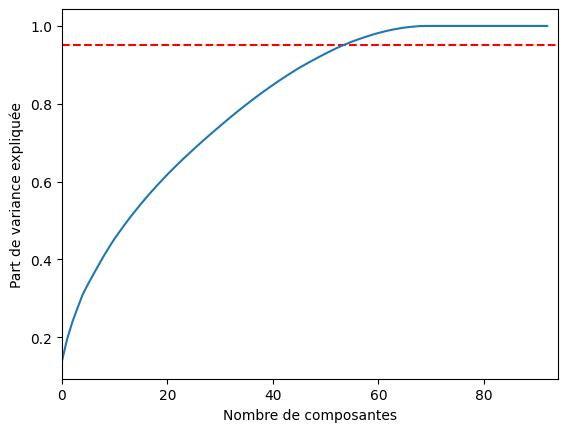

In [39]:
# Nombre de composantes pour 95% dela variance expliquée cumulée:
plt.figure()
plt.xlim(0,94)
plt.xlabel('Nombre de composantes')
plt.ylabel('Part de variance expliquée')
plt.axhline(y = 0.95, color ='r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

In [40]:
# On en précisant directement en PCA:
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train)

In [41]:
X_train_pca.shape

(20569, 55)

# Projection sur les 2 premiers axes avec la target en coloration

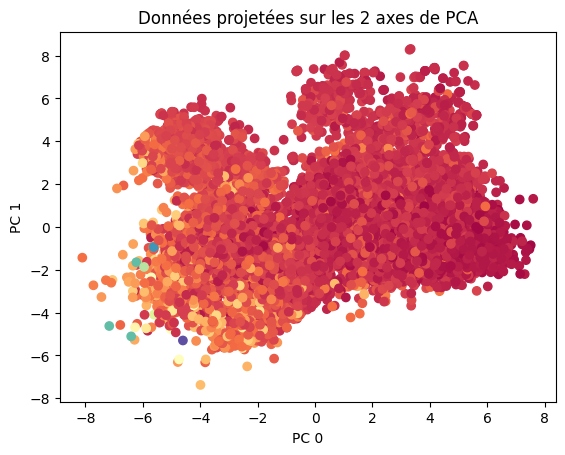

In [42]:
fig = plt.figure()

ax = fig.add_subplot(111)
ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c = np.array(y_train), cmap=plt.cm.Spectral)

ax.set_xlabel('PC 0')
ax.set_ylabel('PC 1')


ax.set_title("Données projetées sur les 2 axes de PCA")
plt.show();


Pas de séparation nette de la target en projetant que les 2 premiers axes PCA

In [43]:
pca.components_.shape

(55, 93)

In [44]:
pca.components_

array([[ 0.16112109, -0.17461276, -0.14949509, ..., -0.2019032 ,
         0.2019032 , -0.2019032 ],
       [-0.00468226, -0.18042817, -0.1003379 , ...,  0.12991149,
        -0.12991149,  0.12991149],
       [ 0.05801541, -0.02536886, -0.0205018 , ...,  0.24039712,
        -0.24039712,  0.24039712],
       ...,
       [ 0.07132604, -0.04321558, -0.2102116 , ..., -0.0156704 ,
         0.0156704 , -0.0156704 ],
       [-0.21351736, -0.00996059, -0.18300416, ..., -0.02870896,
         0.02870896, -0.02870896],
       [ 0.32668712,  0.10790111, -0.26976282, ...,  0.03015749,
        -0.03015749,  0.03015749]], shape=(55, 93))

In [45]:
feature_contribution = pca.components_.T* np.sqrt(pca.explained_variance_)

In [46]:
feature_contribution.shape

(93, 55)

In [47]:
df_feature_contribution = pd.DataFrame(data=feature_contribution, index = X_train.columns)

In [48]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,0.552601,-1.045128e-02,1.133229e-01,-1.386530e-02,1.155098e-02,-4.313159e-02,-1.464551e-01,-5.149009e-02,0.084057,9.122147e-02,...,-9.885445e-02,9.208910e-02,1.501604e-01,-2.024683e-01,2.093470e-01,3.852086e-01,9.728615e-02,5.336384e-02,-1.558999e-01,2.272112e-01
surface,-0.598874,-4.027338e-01,-4.955361e-02,2.376073e-01,-2.610418e-01,6.950079e-02,-1.485229e-01,3.448545e-02,0.006206,5.123464e-03,...,-1.040355e-02,-4.716498e-02,-2.013396e-02,4.890728e-02,-3.901708e-02,-2.966028e-02,-3.737756e-02,-3.233251e-02,-7.272734e-03,7.504532e-02
surface_terrain,-0.512727,-2.239643e-01,-4.004667e-02,9.801346e-02,-3.880287e-02,1.004235e-02,-2.186147e-01,3.761782e-02,-0.019620,-4.252217e-03,...,-9.781440e-02,-2.129572e-02,-2.123347e-02,-9.343362e-02,3.154648e-01,-4.077559e-02,-2.667748e-01,-1.572735e-01,-1.336207e-01,-1.876203e-01
nb_pieces,-0.627586,-4.090346e-01,-8.624962e-02,2.609417e-01,-2.679722e-01,4.415905e-02,-1.617510e-01,4.576275e-02,0.017621,2.512582e-03,...,-6.476186e-02,-2.599530e-02,-6.208323e-03,3.842458e-02,-3.278371e-02,-5.174924e-02,-4.215226e-03,-1.907382e-02,1.124116e-02,1.053857e-01
mensualiteFinance,0.000000,3.097662e-16,-3.252939e-16,-1.922001e-16,1.801854e-17,8.338617e-17,-2.432097e-16,-1.199261e-16,-0.000000,1.530525e-16,...,4.221492e-16,-1.410606e-16,-5.598929e-17,2.094663e-16,-1.749235e-16,2.048862e-16,1.022369e-16,7.203146e-17,-2.026576e-17,3.474725e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,-0.010940,2.511150e-02,-5.414877e-02,2.347294e-02,2.329468e-02,-2.809790e-02,3.311871e-02,-3.401314e-02,-0.007412,-2.006254e-02,...,-3.321156e-03,4.897232e-02,-1.433235e-02,2.910002e-02,-1.083155e-02,-1.012906e-02,-9.680011e-03,5.172143e-03,4.596761e-03,6.370751e-03
TYP_IRIS_x_H,0.693064,-2.913315e-01,-4.666505e-01,1.788151e-01,-2.253673e-01,-1.376106e-01,1.497049e-01,5.708500e-02,-0.141765,1.141278e-01,...,-1.986153e-03,-8.305529e-02,-3.641455e-02,-1.199109e-02,7.115226e-03,3.904280e-02,-1.151807e-02,1.144485e-02,2.071372e-02,-2.131854e-02
TYP_IRIS_x_Z,-0.692472,2.899755e-01,4.695736e-01,-1.800823e-01,2.241094e-01,1.391275e-01,-1.514928e-01,-5.524859e-02,0.142165,-1.130446e-01,...,2.165459e-03,8.041122e-02,3.718831e-02,1.041998e-02,-6.530428e-03,-3.849590e-02,1.204068e-02,-1.172408e-02,-2.096188e-02,2.097456e-02
TYP_IRIS_y_H,0.692472,-2.899755e-01,-4.695736e-01,1.800823e-01,-2.241094e-01,-1.391275e-01,1.514928e-01,5.524859e-02,-0.142165,1.130446e-01,...,-2.165459e-03,-8.041122e-02,-3.718831e-02,-1.041998e-02,6.530428e-03,3.849590e-02,-1.204068e-02,1.172408e-02,2.096188e-02,-2.097456e-02


In [49]:
df_feature_contribution = df_feature_contribution.abs()

In [50]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,0.552601,1.045128e-02,1.133229e-01,1.386530e-02,1.155098e-02,4.313159e-02,1.464551e-01,5.149009e-02,0.084057,9.122147e-02,...,9.885445e-02,9.208910e-02,1.501604e-01,2.024683e-01,2.093470e-01,3.852086e-01,9.728615e-02,5.336384e-02,1.558999e-01,2.272112e-01
surface,0.598874,4.027338e-01,4.955361e-02,2.376073e-01,2.610418e-01,6.950079e-02,1.485229e-01,3.448545e-02,0.006206,5.123464e-03,...,1.040355e-02,4.716498e-02,2.013396e-02,4.890728e-02,3.901708e-02,2.966028e-02,3.737756e-02,3.233251e-02,7.272734e-03,7.504532e-02
surface_terrain,0.512727,2.239643e-01,4.004667e-02,9.801346e-02,3.880287e-02,1.004235e-02,2.186147e-01,3.761782e-02,0.019620,4.252217e-03,...,9.781440e-02,2.129572e-02,2.123347e-02,9.343362e-02,3.154648e-01,4.077559e-02,2.667748e-01,1.572735e-01,1.336207e-01,1.876203e-01
nb_pieces,0.627586,4.090346e-01,8.624962e-02,2.609417e-01,2.679722e-01,4.415905e-02,1.617510e-01,4.576275e-02,0.017621,2.512582e-03,...,6.476186e-02,2.599530e-02,6.208323e-03,3.842458e-02,3.278371e-02,5.174924e-02,4.215226e-03,1.907382e-02,1.124116e-02,1.053857e-01
mensualiteFinance,0.000000,3.097662e-16,3.252939e-16,1.922001e-16,1.801854e-17,8.338617e-17,2.432097e-16,1.199261e-16,0.000000,1.530525e-16,...,4.221492e-16,1.410606e-16,5.598929e-17,2.094663e-16,1.749235e-16,2.048862e-16,1.022369e-16,7.203146e-17,2.026576e-17,3.474725e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,0.010940,2.511150e-02,5.414877e-02,2.347294e-02,2.329468e-02,2.809790e-02,3.311871e-02,3.401314e-02,0.007412,2.006254e-02,...,3.321156e-03,4.897232e-02,1.433235e-02,2.910002e-02,1.083155e-02,1.012906e-02,9.680011e-03,5.172143e-03,4.596761e-03,6.370751e-03
TYP_IRIS_x_H,0.693064,2.913315e-01,4.666505e-01,1.788151e-01,2.253673e-01,1.376106e-01,1.497049e-01,5.708500e-02,0.141765,1.141278e-01,...,1.986153e-03,8.305529e-02,3.641455e-02,1.199109e-02,7.115226e-03,3.904280e-02,1.151807e-02,1.144485e-02,2.071372e-02,2.131854e-02
TYP_IRIS_x_Z,0.692472,2.899755e-01,4.695736e-01,1.800823e-01,2.241094e-01,1.391275e-01,1.514928e-01,5.524859e-02,0.142165,1.130446e-01,...,2.165459e-03,8.041122e-02,3.718831e-02,1.041998e-02,6.530428e-03,3.849590e-02,1.204068e-02,1.172408e-02,2.096188e-02,2.097456e-02
TYP_IRIS_y_H,0.692472,2.899755e-01,4.695736e-01,1.800823e-01,2.241094e-01,1.391275e-01,1.514928e-01,5.524859e-02,0.142165,1.130446e-01,...,2.165459e-03,8.041122e-02,3.718831e-02,1.041998e-02,6.530428e-03,3.849590e-02,1.204068e-02,1.172408e-02,2.096188e-02,2.097456e-02


In [51]:
df_feature_contribution['mean_contribution'] = df_feature_contribution.mean(axis=1)

In [52]:
df_feature_contribution['mean_contribution'].sort_values(ascending=False)

ges_G                     1.082504e-01
dpe_C                     1.073241e-01
dpe_F                     1.049778e-01
Latitude_scaled           1.049550e-01
dpe_G                     1.043816e-01
                              ...     
DEP                       6.357893e-17
chauf_inconnu             5.241646e-17
energie_inconnue          3.234864e-17
chauffage_mode_inconnu    6.496316e-18
type_annonceur_pr         4.172076e-18
Name: mean_contribution, Length: 93, dtype: float64

In [53]:
# Pour différentes valeurs d'un seuil de contribution, on regarde combien de features on garderait

for threshold in [0.1, 0.08, 0.06, 0.04, 0.02, 0.01]:
    feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > threshold]
    index_selected = feature_selected.index
    print(f"seuil: {threshold}, nombre de features selectionnées: {len(index_selected)}")

seuil: 0.1, nombre de features selectionnées: 14
seuil: 0.08, nombre de features selectionnées: 46
seuil: 0.06, nombre de features selectionnées: 77
seuil: 0.04, nombre de features selectionnées: 86
seuil: 0.02, nombre de features selectionnées: 86
seuil: 0.01, nombre de features selectionnées: 86


In [54]:
feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > 0.06]
feature_selected = feature_selected['mean_contribution'].sort_values(ascending=False)
features_selected_pca = list(feature_selected.index)
features_selected_pca[:20]

['ges_G',
 'dpe_C',
 'dpe_F',
 'Latitude_scaled',
 'dpe_G',
 'ges_A',
 'energie_elec',
 'dpe_B',
 'annee_construction',
 'chauf_convecteur',
 'dpe_E',
 'categorie_annonceur_m',
 'dpe_D',
 'dpe_A',
 'cave',
 'ges_E',
 'ges_D',
 'expo_nord',
 'ges_C',
 'Longitude_scaled']

In [60]:
## La PCA ne semble pas donner de résultst pertinents, la surface et le nombre de pièces ne sont même pas présents.

## 14.3) Matthieu

### 14.3.1) LinearRegression

LinearRegression sur l'ensemble des Features

In [61]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Scores
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

MAE  : 59317.55
RMSE : 90179.78
R2   : 0.6789


Coefficients des Features

In [62]:
# Création du dictionnaire avec les coefficients absolus
columns_coef = dict(zip(X_train.columns, np.abs(lr.coef_[0]).tolist()))

# Tri par ordre décroissant des coefficients
columns_coef_trie = dict(sorted(columns_coef.items(), key=lambda item: item[1], reverse=True))

# Création du DataFrame avec l'ordre, la feature et le coefficient
df_resultats = pd.DataFrame([
    {'Ordre d\'importance': i, 'Feature': feature, 'Coefficient en valeur absolue': coef}
    for i, (feature, coef) in enumerate(columns_coef_trie.items(), start=1)
])

df_resultats.head(10)


,Ordre d'importance,Feature,Coefficient en valeur absolue
0,1,avg_commune_type_pieces,91490.623708
1,2,surface,76479.548420
2,3,nb_pieces,47495.494172
3,4,surface_terrain,19498.018228
4,5,energie_gaz,16943.103295
5,6,energie_elec,12825.912898
6,7,energie_fioul,12348.576871
7,8,dpe_A,10636.580762
8,9,annee_construction,9609.450788
9,10,UU2010,8757.163676


In [63]:
features_selected_lr = df_resultats['Feature'].tolist()
features_selected_lr

['avg_commune_type_pieces',
 'surface',
 'nb_pieces',
 'surface_terrain',
 'energie_gaz',
 'energie_elec',
 'energie_fioul',
 'dpe_A',
 'annee_construction',
 'UU2010',
 'IRIS',
 'nb_toilettes',
 'eau',
 'dpe_E',
 'dpe_B',
 'dpeC',
 'Longitude_scaled',
 'bain',
 'annee_2023',
 'annee_2020',
 'dpe_inconnu',
 'nb_etages',
 'dpe_D',
 'logement_neuf',
 'dpe_F',
 'expo_sud',
 'categorie_annonceur_a',
 'annonce_exclusive_Oui',
 'annee_2022',
 'categorie_annonceur_cm',
 'categorie_annonceur_ca',
 'annee_2019',
 'chauf_pac',
 'expo_est',
 'chauffage_mode_individuel',
 'Latitude_scaled',
 'ascenseur',
 'annonce_exclusive_0',
 'typedetransaction_vp',
 'typedetransaction_v',
 'energie_bois',
 'categorie_annonceur_b',
 'nb_logements_copro',
 'annee_2021',
 'balcon',
 'chauffage_mode_central',
 'ges_G',
 'annonce_exclusive_Non',
 'ges_C',
 'dpe_G',
 'typedebien_m',
 'typedebien_lite_m',
 'typedebien_lite_a',
 'typedebien_a',
 'dpe_C',
 'TYP_IRIS_y_H',
 'TYP_IRIS_y_Z',
 'TYP_IRIS_x_Z',
 'ges_inconnu

<Axes: >

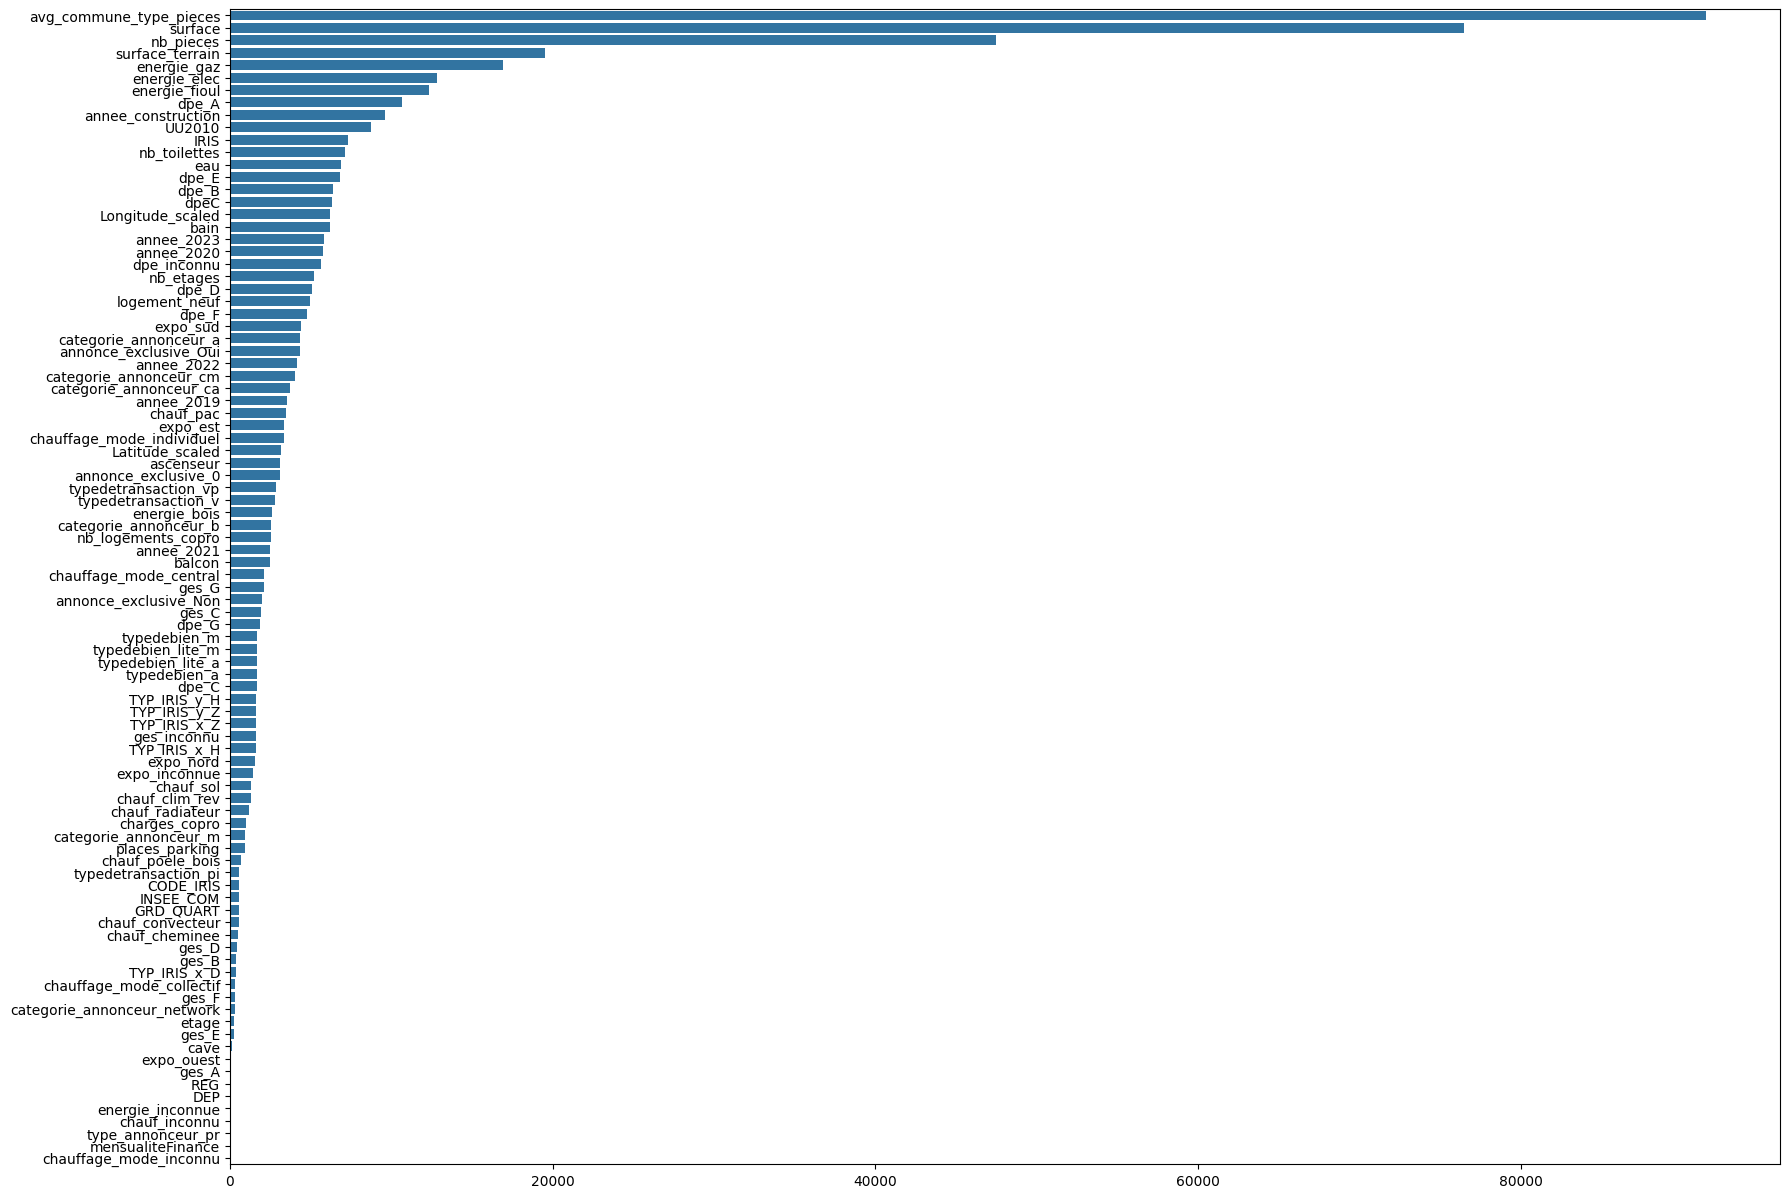

In [64]:
fig, ax = plt.subplots(figsize = (20,15))
sns.barplot(x=columns_coef_trie.values(), y=columns_coef_trie.keys())

LinearRegression en ne gardant que les 10 plus gros coefficient

In [65]:
lr_10 = LinearRegression()
lr_10.fit(X_train[df_resultats.Feature[:10].values.tolist()], y_train)

y_pred_lr_10 = lr_10.predict(X_test[df_resultats.Feature[:10].values.tolist()])

# Scores
mae_lr_10 = mean_absolute_error(y_test, y_pred_lr_10)
rmse_lr_10 = np.sqrt(mean_squared_error(y_test, y_pred_lr_10))
r2_lr_10 = r2_score(y_test, y_pred_lr_10)

print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")


MAE  : 66014.70
RMSE : 99038.32
R2   : 0.6127


Comparaison LinearRegression avec 94 Features et 10 Features

In [66]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 59317.55
RMSE : 90179.78
R2   : 0.6789

### Linear Regresion avec 10 Features ###
MAE  : 66014.70
RMSE : 99038.32
R2   : 0.6127


### 14.3.2) LinearRegression + Backward Elimination

SequentialFeatureSelector (backward)

Features retenues : Index(['surface', 'surface_terrain', 'nb_pieces', 'balcon', 'eau', 'bain',
       'dpeC', 'nb_etages', 'annee_construction', 'nb_toilettes', 'ascenseur',
       'nb_logements_copro', 'logement_neuf', 'CODE_IRIS', 'GRD_QUART',
       'UU2010', 'Latitude_scaled', 'Longitude_scaled',
       'avg_commune_type_pieces', 'annee_2019', 'annee_2020', 'annee_2021',
       'annee_2023', 'expo_nord', 'expo_sud', 'expo_est', 'chauf_sol',
       'chauf_pac', 'chauf_clim_rev', 'dpe_A', 'dpe_B', 'dpe_C', 'dpe_D',
       'dpe_inconnu', 'ges_C', 'ges_G', 'ges_inconnu',
       'chauffage_mode_individuel', 'chauffage_mode_central',
       'typedetransaction_vp', 'annonce_exclusive_Oui',
       'categorie_annonceur_a', 'categorie_annonceur_b',
       'categorie_annonceur_ca', 'categorie_annonceur_cm', 'typedebien_lite_a',
       'TYP_IRIS_y_Z'],
      dtype='object')
MAE  : 59360.36
RMSE : 90252.55
R2   : 0.6784


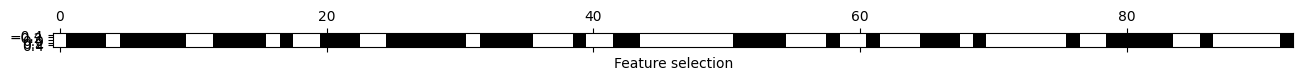

In [67]:
lr_backward_auto = LinearRegression()

# Backward Selection (recul)
sfs = SequentialFeatureSelector(
    lr_backward_auto,
    n_features_to_select='auto',
    direction="backward",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error"
)

sfs.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = sfs.get_support()
selected_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", selected_features)

# Modèle final sur features retenues
lr_backward_auto.fit(X_train[selected_features], y_train)
y_pred_lr_backward_auto = lr_backward_auto.predict(X_test[selected_features])

mae_lr_backward_auto = mean_absolute_error(y_test, y_pred_lr_backward_auto)
rmse_lr_backward_auto = np.sqrt(mean_squared_error(y_test, y_pred_lr_backward_auto))
r2_lr_backward_auto = r2_score(y_test, y_pred_lr_backward_auto)

print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")


In [68]:
features_selected_sfs = selected_features
len(features_selected_sfs)

47

In [69]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 59317.55
RMSE : 90179.78
R2   : 0.6789

### Linear Regresion avec 10 Features ###
MAE  : 66014.70
RMSE : 99038.32
R2   : 0.6127

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 59360.36
RMSE : 90252.55
R2   : 0.6784


### 14.4.3) LinearRegression + SelectKBest

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'balcon', 'eau',
       'bain', 'dpeC', 'nb_etages', 'places_parking', 'nb_toilettes',
       'ascenseur', 'nb_logements_copro', 'charges_copro', 'logement_neuf',
       'IRIS', 'UU2010', 'Longitude_scaled', 'avg_commune_type_pieces',
       'annee_2020', 'annee_2022', 'annee_2023', 'expo_sud', 'chauf_sol',
       'energie_gaz', 'energie_elec', 'energie_fioul', 'dpe_A', 'dpe_B',
       'dpe_E', 'ges_A', 'chauffage_mode_individuel',
       'chauffage_mode_collectif', 'typedebien_a', 'typedebien_m',
       'typedetransaction_v', 'typedetransaction_vp', 'annonce_exclusive_0',
       'annonce_exclusive_Oui', 'categorie_annonceur_a',
       'categorie_annonceur_cm', 'typedebien_lite_a', 'typedebien_lite_m',
       'TYP_IRIS_x_H', 'TYP_IRIS_x_Z', 'TYP_IRIS_y_H', 'TYP_IRIS_y_Z'],
      dtype='object')
MAE  : 60666.52
RMSE : 91530.59
R2   : 0.6692


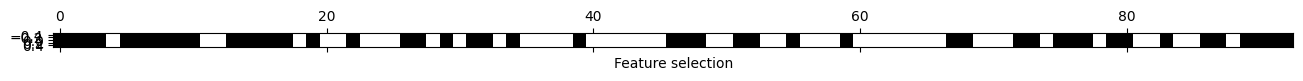

In [77]:
# Choix de K
k = 47

# SelectKBest
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = selector.get_support()
kbest_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", kbest_features)

# Modèle final
lr_kbest = LinearRegression()
lr_kbest.fit(X_train[kbest_features], y_train)

y_pred_kbest = lr_kbest.predict(X_test[kbest_features])

mae_kbest = mean_absolute_error(y_test, y_pred_kbest)
rmse_kbest = np.sqrt(mean_squared_error(y_test, y_pred_kbest))
r2_kbest = r2_score(y_test, y_pred_kbest)

print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")


In [78]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 59317.55
RMSE : 90179.78
R2   : 0.6789

### Linear Regresion avec 10 Features ###
MAE  : 66014.70
RMSE : 99038.32
R2   : 0.6127

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 59360.36
RMSE : 90252.55
R2   : 0.6784

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 60666.52
RMSE : 91530.59
R2   : 0.6692


In [79]:
features_selected_kbest = kbest_features
len(features_selected_kbest)

47

In [90]:
selected_dict = { 'pca': features_selected_pca,
                  'lr': features_selected_lr,
                  'sfs': features_selected_sfs,
                  'kbest': features_selected_kbest}

In [81]:
joblib.dump(selected_dict, "selected_dict_12102026.joblib")

['selected_dict_12102026.joblib']

In [91]:
selected_dict = joblib.load("selected_dict_12102026.joblib")

In [92]:
selected_dict.keys()

dict_keys(['pca', 'lr', 'sfs', 'kbest'])

## 14.4) Intersection

In [93]:
#si l'on regarde l'intersection entre les features sélectionnées par la PCA et les features sélectionnées par la lr:
selected = set(selected_dict['lr'][:47]).intersection(set(selected_dict['sfs'])).intersection(set(selected_dict['kbest']))
selected = list(selected)
selected

['annee_2020',
 'annee_2023',
 'nb_pieces',
 'avg_commune_type_pieces',
 'balcon',
 'dpeC',
 'Longitude_scaled',
 'nb_logements_copro',
 'UU2010',
 'dpe_A',
 'ascenseur',
 'categorie_annonceur_cm',
 'nb_toilettes',
 'bain',
 'dpe_B',
 'annonce_exclusive_Oui',
 'expo_sud',
 'surface_terrain',
 'surface',
 'chauffage_mode_individuel',
 'nb_etages',
 'logement_neuf',
 'categorie_annonceur_a',
 'eau',
 'typedetransaction_vp']

In [94]:
len(selected)

25

In [95]:
# Si on essaie une régression avec ces  features:
lr_selected = LinearRegression()
lr_selected.fit(X_train[selected], y_train)

# Prédictions
y_pred_selected = lr_selected.predict(X_test[selected])

# Scores
mae_selected = mean_absolute_error(y_test, y_pred_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))
r2_selected = r2_score(y_test, y_pred_selected)

print(f"MAE  : {mae_selected:.2f}")
print(f"RMSE : {rmse_selected:.2f}")
print(f"R2   : {r2_selected:.4f}")


MAE  : 61465.18
RMSE : 92531.15
R2   : 0.6620


In [96]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

print("\n### Linear Regresion avec les selected Features (intersection des méthodes précédentes) ###")
print(f"MAE  : {mae_selected:.2f}")
print(f"RMSE : {rmse_selected:.2f}")
print(f"R2   : {r2_selected:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 59317.55
RMSE : 90179.78
R2   : 0.6789

### Linear Regresion avec 10 Features ###
MAE  : 66014.70
RMSE : 99038.32
R2   : 0.6127

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 59360.36
RMSE : 90252.55
R2   : 0.6784

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 60666.52
RMSE : 91530.59
R2   : 0.6692

### Linear Regresion avec les selected Features (intersection des méthodes précédentes) ###
MAE  : 61465.18
RMSE : 92531.15
R2   : 0.6620


On est un peu moins bien que pour uniquement les 20 features mais on est sur un seul type de modèle (régression linéaire). On verra par la suite avec les autres modèles et en optimisant ce que l'on obtiendra...

#### Découpage X et y par type de bien

In [131]:
X_train_appartements = X_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_train_sans_scaler_appartements = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
y_train_appartements = y_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_test_appartements = X_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
X_test_sans_scaler_appartements = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
y_test_appartements = y_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]

X_train_maisons = X_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_train_sans_scaler_maisons = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
y_train_maisons = y_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_test_maisons = X_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
X_test_sans_scaler_maisons = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
y_test_maisons = y_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]

In [132]:
print(X_train.shape)
print(y_train.shape)
print(X_train_appartements.shape)
print(X_train_sans_scaler_appartements.shape)
print(y_train_appartements.shape)
print(X_train_maisons.shape)
print(X_train_sans_scaler_maisons.shape)
print(y_train_maisons.shape)

(20569, 93)
(20569, 1)
(10192, 93)
(10192, 93)
(10192, 1)
(10377, 93)
(10377, 93)
(10377, 1)


In [133]:
print(X_test.shape)
print(y_test.shape)
print(X_test_appartements.shape)
print(X_test_sans_scaler_appartements.shape)
print(y_test_appartements.shape)
print(X_test_maisons.shape)
print(X_test_sans_scaler_maisons.shape)
print(y_test_maisons.shape)

(5127, 93)
(5127, 1)
(2502, 93)
(2502, 93)
(2502, 1)
(2625, 93)
(2625, 93)
(2625, 1)


In [97]:
### TO CONTINUE

#### DecisionTreeRegressor() sans target encoding

In [142]:
tree = DecisionTreeRegressor()

tree.fit(X_train.drop('avg_commune_type_pieces', axis=1), y_train)

tree_pred = tree.predict(X_test.drop('avg_commune_type_pieces', axis=1))
tree_pred = pd.DataFrame(tree_pred, index=y_test.index, columns=['prix_bien'])

mae_tree = mean_absolute_error(y_test, tree_pred)
rmse_tree = np.sqrt(mean_squared_error(y_test, tree_pred))
r2_tree = r2_score(y_test, tree_pred)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

MAE  : 62150.66
RMSE : 103846.05
R2   : 0.5742


In [143]:
importance = tree.feature_importances_
feature_names = X_train.drop('avg_commune_type_pieces', axis=1).columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)

,Feature,Importance
1,surface,0.508010
26,Longitude_scaled,0.105059
25,Latitude_scaled,0.044376
8,dpeC,0.041329
2,surface_terrain,0.038921
...,...,...
49,energie_inconnue,0.000000
44,chauf_inconnu,0.000000
73,typedetransaction_pi,0.000000
69,chauffage_mode_inconnu,0.000000


In [144]:
tree_diff = y_test - tree_pred

<Axes: ylabel='Count'>

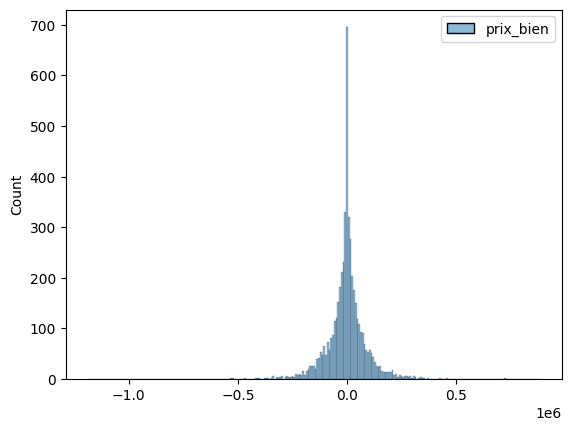

In [145]:
sns.histplot(tree_diff)

#### DecisionTreeRegressor() avec target encoding

In [146]:
tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
tree_pred = pd.DataFrame(tree_pred, index=y_test.index, columns=['prix_bien'])

mae_tree = mean_absolute_error(y_test, tree_pred)
rmse_tree = np.sqrt(mean_squared_error(y_test, tree_pred))
r2_tree = r2_score(y_test, tree_pred)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

MAE  : 62778.93
RMSE : 104960.98
R2   : 0.5650


In [147]:
importance = tree.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)

,Feature,Importance
27,avg_commune_type_pieces,0.597542
1,surface,0.108606
8,dpeC,0.034259
2,surface_terrain,0.028582
12,annee_construction,0.025174
...,...,...
50,energie_inconnue,0.000000
74,typedetransaction_pi,0.000000
71,type_annonceur_pr,0.000000
70,chauffage_mode_inconnu,0.000000


In [148]:
tree_diff = y_test - tree_pred

In [149]:
tree_diff

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-108250.0
ag680297-277810664,6500.0
orpi-1-054041E1OWKF,21050.0
guy-hoquet-immo-facile-6243822,-23000.0
ag440414-293552741,113000.0
...,...
immo-facile-35871425,-35000.0
ag680254-273036872,20000.0
ag681158-373018354,15900.0


<Axes: ylabel='Count'>

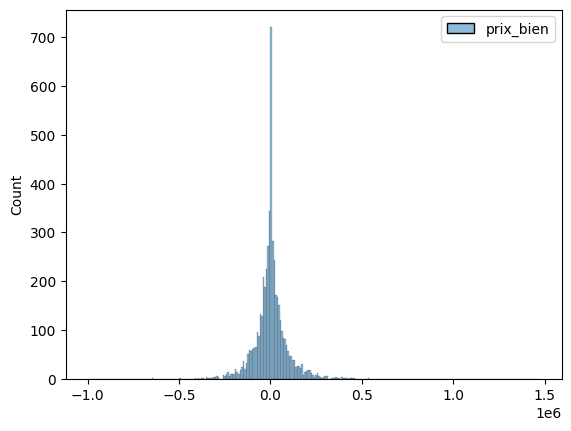

In [150]:
sns.histplot(tree_diff)

In [151]:
X_test.shape

(5127, 93)

In [152]:
df_tree_pred = pd.merge(tree_pred, df_ventes, how='left', left_index=True, right_index=True)
df_tree_pred['delta_prediction'] = df_tree_pred['prix_bien_y'] - df_tree_pred['prix_bien_x']
df_tree_pred.shape

(5127, 60)

In [153]:
df_tree_pred.sort_values(by='prix_bien_y', ascending=False)[['prix_bien_y','prix_bien_x', 'delta_prediction']].head()

,prix_bien_y,prix_bien_x,delta_prediction
idannonce,,,
ag681120-337284537,2300000,830000.0,1470000.0
immo-facile-51101837,1670000,1104000.0,566000.0
hektor-dagon68390-2443,1295000,367500.0,927500.0
immo-facile-40221393,1250000,828000.0,422000.0
safti-1-690910,1180000,988000.0,192000.0


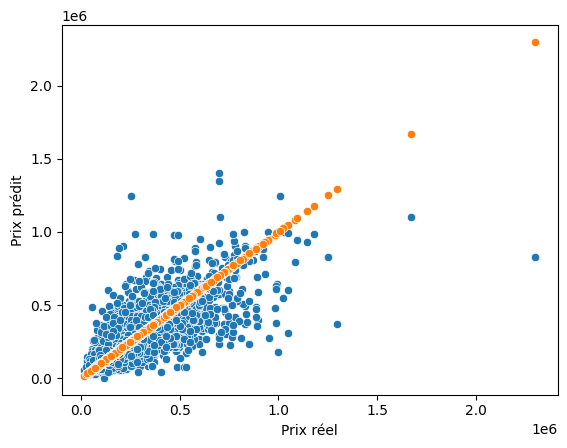

In [154]:
sns.scatterplot(data=df_tree_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel')
plt.ylabel('Prix prédit');

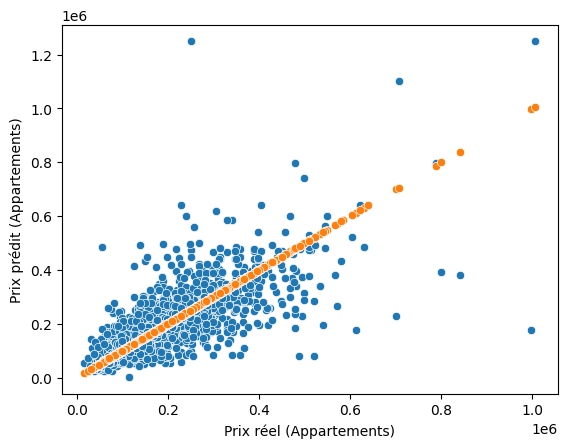

In [155]:
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'a'], x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'a'], x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Appartements)')
plt.ylabel('Prix prédit (Appartements)');

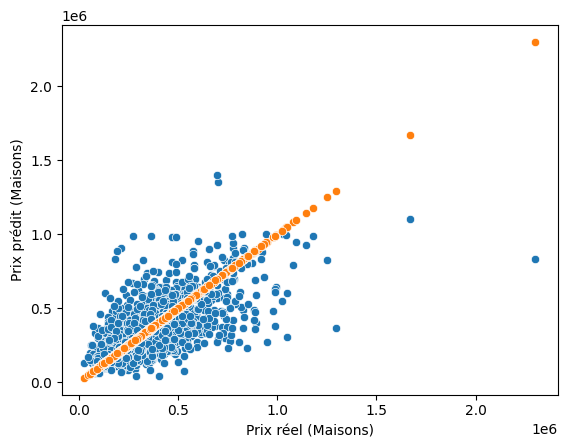

In [156]:
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'm'], x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'm'], x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Maisons)')
plt.ylabel('Prix prédit (Maisons)');

In [160]:
np.abs(df_tree_pred[df_tree_pred['typedebien_lite'] == 'm']['delta_prediction']).mean()

np.float64(83417.02552380953)

In [161]:
np.abs(df_tree_pred[df_tree_pred['typedebien_lite'] == 'a']['delta_prediction']).mean()

np.float64(41126.24980015987)

In [162]:
df_train = pd.merge(X_train, df_ventes, how='left', left_index=True, right_index=True)
df_train['typedebien_lite'] == 'a'

idannonce
ag681108-285757544               True
ag680297-340567902              False
hektor-girardi-pfastatt-2683    False
orpi-1-054928E2CVGG             False
ag671791-287402273               True
                                ...  
ag440414-273408896               True
ag681391-366397327              False
orpi-1-054039E2F462             False
ag681122-315221046               True
iad-france-782156               False
Name: typedebien_lite, Length: 20569, dtype: bool

## 17.2) Distinction des modèles

#### DecisionTreeRegressor() sur Appartements

In [163]:
tree_a = DecisionTreeRegressor()

tree_a.fit(X_train[df_train['typedebien_lite'] == 'a'], y_train[df_train['typedebien_lite'] == 'a'])

tree_a_pred = tree_a.predict(X_test[df_tree_pred['typedebien_lite'] == 'a'])
tree_a_pred = pd.DataFrame(tree_a_pred, index=y_test[df_tree_pred['typedebien_lite'] == 'a'].index, columns=['prix_bien'])

mae_tree_a = mean_absolute_error(y_test[df_tree_pred['typedebien_lite'] == 'a'], tree_a_pred)
rmse_tree_a = np.sqrt(mean_squared_error(y_test[df_tree_pred['typedebien_lite'] == 'a'], tree_a_pred))
r2_tree_a = r2_score(y_test[df_tree_pred['typedebien_lite'] == 'a'], tree_a_pred)

print(f"MAE  : {mae_tree_a:.2f}")
print(f"RMSE : {rmse_tree_a:.2f}")
print(f"R2   : {r2_tree_a:.4f}")

MAE  : 40350.00
RMSE : 66784.49
R2   : 0.5660


In [164]:
df_tree_a_pred = pd.merge(tree_a_pred, df_ventes, how='left', left_index=True, right_index=True)

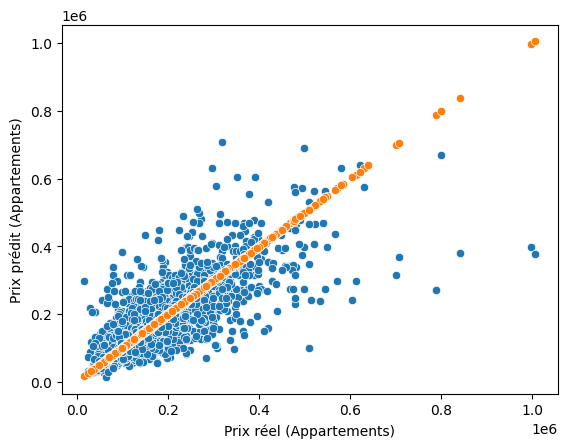

In [165]:
sns.scatterplot(data=df_tree_a_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_a_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Appartements)')
plt.ylabel('Prix prédit (Appartements)');

#### DecisionTreeRegressor() sur Maisons

In [166]:
tree_m = DecisionTreeRegressor()

tree_m.fit(X_train[df_train['typedebien_lite'] == 'm'], y_train[df_train['typedebien_lite'] == 'm'])

tree_m_pred = tree_m.predict(X_test[df_tree_pred['typedebien_lite'] == 'm'])
tree_m_pred = pd.DataFrame(tree_m_pred, index=y_test[df_tree_pred['typedebien_lite'] == 'm'].index, columns=['prix_bien'])

mae_tree_m = mean_absolute_error(y_test[df_tree_pred['typedebien_lite'] == 'm'], tree_m_pred)
rmse_tree_m = np.sqrt(mean_squared_error(y_test[df_tree_pred['typedebien_lite'] == 'm'], tree_m_pred))
r2_tree_m = r2_score(y_test[df_tree_pred['typedebien_lite'] == 'm'], tree_m_pred)

print(f"MAE  : {mae_tree_m:.2f}")
print(f"RMSE : {rmse_tree_m:.2f}")
print(f"R2   : {r2_tree_m:.4f}")

MAE  : 81390.07
RMSE : 125011.35
R2   : 0.4377


In [167]:
df_tree_m_pred = pd.merge(tree_m_pred, df_ventes, how='left', left_index=True, right_index=True)

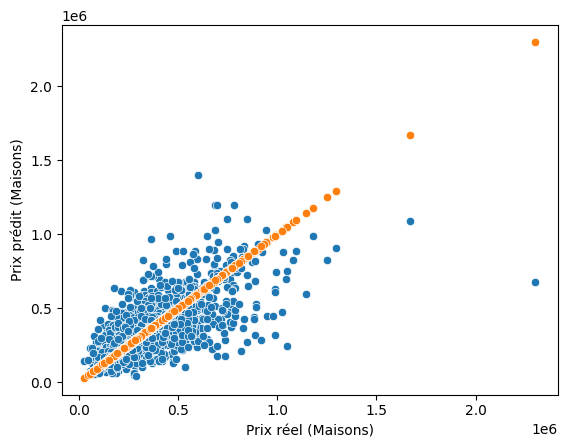

In [168]:
sns.scatterplot(data=df_tree_m_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_m_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Maisons)')
plt.ylabel('Prix prédit (Maisons)');

In [169]:
X_test_maisons = X_test[df_tree_pred['typedebien_lite'] == 'm']
y_test_maisons = y_test[df_tree_pred['typedebien_lite'] == 'm']

lr_m = LinearRegression()

lr_m.fit(X_train[df_train['typedebien_lite'] == 'm'], y_train[df_train['typedebien_lite'] == 'm'])

lr_m_pred = lr_m.predict(X_test_maisons)
lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_maisons.index, columns=['prix_bien'])

mae_lr_m = mean_absolute_error(y_test_maisons, lr_m_pred)
rmse_lr_m = np.sqrt(mean_squared_error(y_test_maisons, lr_m_pred))
r2_lr_m = r2_score(y_test_maisons, lr_m_pred)

print(f"MAE  : {mae_lr_m:.2f}")
print(f"RMSE : {rmse_lr_m:.2f}")
print(f"R2   : {r2_lr_m:.4f}")

MAE  : 73803.54
RMSE : 108587.53
R2   : 0.5757


In [170]:
df_lr_m_pred = pd.merge(lr_m_pred, df_ventes, how='left', left_index=True, right_index=True)

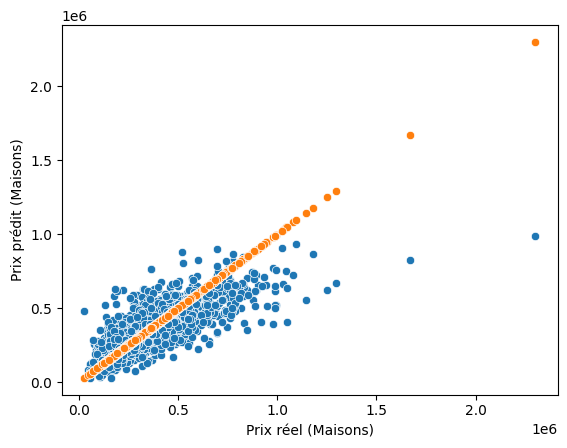

In [171]:
sns.scatterplot(data=df_lr_m_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_lr_m_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Maisons)')
plt.ylabel('Prix prédit (Maisons)');

## 17.3) Suppression des outliers

In [186]:
X_test_maisons_sans_outlier = X_test[(df_tree_pred['typedebien_lite'] == 'm') & (df_tree_pred['prix_bien_y'] < 5000000)]
y_test_maisons_sans_outlier = y_test[(df_tree_pred['typedebien_lite'] == 'm') & (df_tree_pred['prix_bien_y'] < 5000000)]

lr_m = LinearRegression()

lr_m.fit(X_train[df_train['typedebien_lite'] == 'm'], y_train[df_train['typedebien_lite'] == 'm'])

score_pieces = []

for nb in np.sort(df_tree_pred.nb_pieces.unique()):

    lr_m_pred = lr_m.predict(X_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb])
    lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])

    mae_lr_m = mean_absolute_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
    rmse_lr_m = np.sqrt(mean_squared_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred))
    r2_lr_m = r2_score(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred)

    print(f"{nb} pieces :")
    print(f"MAE  : {mae_lr_m:.2f}")
    print(f"RMSE : {rmse_lr_m:.2f}")
    print(f"R2   : {r2_lr_m:.4f}")
    score_pieces.append({"pieces":nb, "MAE": mae_lr_m, "RMSE":rmse_lr_m, "R2":r2_lr_m})
    print('\n')

/tmp/user/1000/ipykernel_2065841/3317031644.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = lr_m.predict(X_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb])
/tmp/user/1000/ipykernel_2065841/3317031644.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])
/tmp/user/1000/ipykernel_2065841/3317031644.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mae_lr_m = mean_absolute_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
/tmp/user/1000/ipykernel_2065841/3317031644.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rmse_lr_m = np.sqrt(mean_squared_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred))
/tmp/user/1000/ipykernel_2065841/3317031644.py:

1 pieces :
MAE  : 58221.11
RMSE : 86598.61
R2   : 0.5755


2 pieces :
MAE  : 97583.31
RMSE : 107312.30
R2   : -8.6686


3 pieces :
MAE  : 57361.46
RMSE : 91119.15
R2   : -0.0194


4 pieces :
MAE  : 52536.14
RMSE : 73534.18
R2   : 0.4403


5 pieces :
MAE  : 60697.67
RMSE : 83433.90
R2   : 0.5691


6 pieces :
MAE  : 77921.67
RMSE : 102993.23
R2   : 0.5366


7 pieces :
MAE  : 100382.74
RMSE : 138167.41
R2   : 0.6026


8 pieces :
MAE  : 135179.07
RMSE : 212232.05
R2   : 0.4387


9 pieces :
MAE  : 154854.83
RMSE : 215395.29
R2   : 0.3327


10 pieces :
MAE  : 139718.13
RMSE : 190035.88
R2   : 0.2717


11 pieces :
MAE  : 143601.54
RMSE : 203961.40
R2   : 0.2742


12 pieces :
MAE  : 104532.70
RMSE : 157564.32
R2   : 0.2841




/tmp/user/1000/ipykernel_2065841/3317031644.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rmse_lr_m = np.sqrt(mean_squared_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred))
/tmp/user/1000/ipykernel_2065841/3317031644.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  r2_lr_m = r2_score(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
/tmp/user/1000/ipykernel_2065841/3317031644.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = lr_m.predict(X_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb])
/tmp/user/1000/ipykernel_2065841/3317031644.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])
/tmp/user/1000/ipykernel_2065841/3317031644.py:15: UserWarn

In [187]:
pd.DataFrame(score_pieces).sort_values(by='pieces')


,pieces,MAE,RMSE,R2
0,1,58221.107919,86598.605133,0.575546
1,2,97583.311152,107312.304409,-8.668557
2,3,57361.457295,91119.149517,-0.019443
3,4,52536.136081,73534.177707,0.440252
4,5,60697.666420,83433.898629,0.569116
5,6,77921.668455,102993.228643,0.536616
6,7,100382.738037,138167.408651,0.602644
7,8,135179.065489,212232.054070,0.438691
8,9,154854.825595,215395.285901,0.332672
9,10,139718.132105,190035.883234,0.271654


In [188]:
df_lr_m_pred = pd.merge(lr_m_pred, df_ventes, how='left', left_index=True, right_index=True)

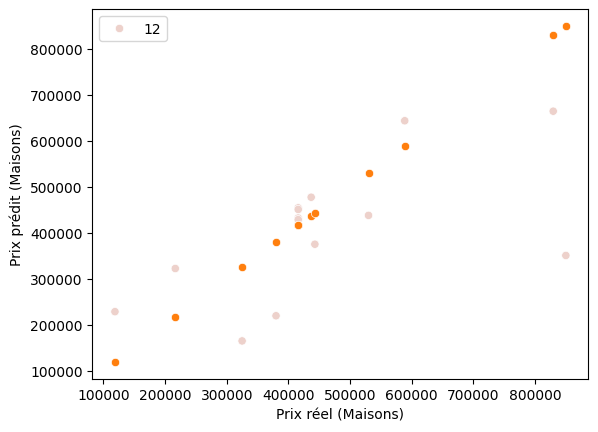

In [189]:
for nb in df_lr_m_pred.nb_pieces.unique():
    sns.scatterplot(data=df_lr_m_pred[df_lr_m_pred['nb_pieces'] == nb], x='prix_bien_y', y='prix_bien_x', hue='nb_pieces')
    sns.scatterplot(data=df_lr_m_pred[df_lr_m_pred['nb_pieces'] == nb], x='prix_bien_y', y='prix_bien_y')
    plt.xlabel('Prix réel (Maisons)')
    plt.ylabel('Prix prédit (Maisons)')
    plt.show()
    print('\n');

In [190]:
X_test_appartements = X_test[(df_tree_pred['typedebien_lite'] == 'a')]
y_test_appartements = y_test[(df_tree_pred['typedebien_lite'] == 'a')]

lr_m = LinearRegression()

lr_m.fit(X_train[df_train['typedebien_lite'] == 'a'], y_train[df_train['typedebien_lite'] == 'a'])

score_pieces_a = []

for nb in np.sort(df_tree_pred.nb_pieces.unique()):
    try:
        lr_m_pred = lr_m.predict(X_test_appartements[df_tree_pred['nb_pieces'] == nb])
        lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_appartements[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])

        mae_lr_m = mean_absolute_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
        rmse_lr_m = np.sqrt(mean_squared_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred))
        r2_lr_m = r2_score(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred)

        print(f"{nb} pieces :")
        print(f"MAE  : {mae_lr_m:.2f}")
        print(f"RMSE : {rmse_lr_m:.2f}")
        print(f"R2   : {r2_lr_m:.4f}")
        score_pieces_a.append({"pieces":nb, "MAE": mae_lr_m, "RMSE":rmse_lr_m, "R2":r2_lr_m})
        print('\n')
    except:
        pass

1 pieces :
MAE  : 33309.43
RMSE : 48839.81
R2   : -0.0050


2 pieces :
MAE  : 26301.25
RMSE : 34129.53
R2   : 0.4677


3 pieces :
MAE  : 33445.31
RMSE : 44111.10
R2   : 0.6243


4 pieces :
MAE  : 41280.47
RMSE : 56236.26
R2   : 0.6543


5 pieces :
MAE  : 60966.78
RMSE : 89753.98
R2   : 0.5552


6 pieces :
MAE  : 87390.64
RMSE : 111652.58
R2   : 0.5611


7 pieces :
MAE  : 112598.05
RMSE : 130095.44
R2   : 0.5788


8 pieces :
MAE  : 127971.67
RMSE : 152547.35
R2   : -0.4928


10 pieces :
MAE  : 216616.09
RMSE : 247057.29
R2   : -151.5933


12 pieces :
MAE  : 220126.77
RMSE : 220126.77
R2   : nan




/tmp/user/1000/ipykernel_2065841/1111587291.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = lr_m.predict(X_test_appartements[df_tree_pred['nb_pieces'] == nb])
/tmp/user/1000/ipykernel_2065841/1111587291.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_appartements[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])
/tmp/user/1000/ipykernel_2065841/1111587291.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mae_lr_m = mean_absolute_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
/tmp/user/1000/ipykernel_2065841/1111587291.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rmse_lr_m = np.sqrt(mean_squared_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred))
/tmp/user/1000/ipykernel_2065841/1111587291.py:17: UserWarning: Boolean Series 

In [191]:
pd.DataFrame(score_pieces_a).sort_values(by='pieces')

,pieces,MAE,RMSE,R2
0,1,33309.426799,48839.810318,-0.004977
1,2,26301.245837,34129.528773,0.467714
2,3,33445.308360,44111.103490,0.624281
3,4,41280.466099,56236.255626,0.654331
4,5,60966.780802,89753.982647,0.555219
5,6,87390.640626,111652.581537,0.561059
6,7,112598.052643,130095.442659,0.578756
7,8,127971.668274,152547.347139,-0.492765
8,10,216616.091888,247057.286766,-151.593257
9,12,220126.767280,220126.767280,NaN


## 17.3) Random Forest

In [192]:
from sklearn.ensemble import RandomForestRegressor

In [193]:
rf = RandomForestRegressor().fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_pred = pd.DataFrame(rf_pred, index=y_test.index, columns=['prix_bien'])

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R2   : {r2_rf:.4f}")

/home/yhov7445/workspace/2025_Parcours_DS/projet/Projet_DS2025/venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 47452.03
RMSE : 80475.82
R2   : 0.7443


In [194]:
rf_pred_maisons = rf.predict(X_test_maisons)
rf_pred_maisons = pd.DataFrame(rf_pred_maisons, index=y_test_maisons.index, columns=['prix_bien'])

mae_rf_maisons = mean_absolute_error(y_test_maisons, rf_pred_maisons)
rmse_rf_maisons = np.sqrt(mean_squared_error(y_test_maisons, rf_pred_maisons))
r2_rf_maisons = r2_score(y_test_maisons, rf_pred_maisons)

print(f"MAE  : {mae_rf_maisons:.2f}")
print(f"RMSE : {rmse_rf_maisons:.2f}")
print(f"R2   : {r2_rf_maisons:.4f}")

MAE  : 63618.68
RMSE : 100900.49
R2   : 0.6337


In [195]:
rf_pred_appartements = rf.predict(X_test_appartements)
rf_pred_appartements = pd.DataFrame(rf_pred_appartements, index=y_test_appartements.index, columns=['prix_bien'])

mae_rf_appartements = mean_absolute_error(y_test_appartements, rf_pred_appartements)
rmse_rf_appartements = np.sqrt(mean_squared_error(y_test_appartements, rf_pred_appartements))
r2_rf_appartements = r2_score(y_test_appartements, rf_pred_appartements)

print(f"MAE  : {mae_rf_appartements:.2f}")
print(f"RMSE : {rmse_rf_appartements:.2f}")
print(f"R2   : {r2_rf_appartements:.4f}")

MAE  : 30490.62
RMSE : 50888.98
R2   : 0.7480


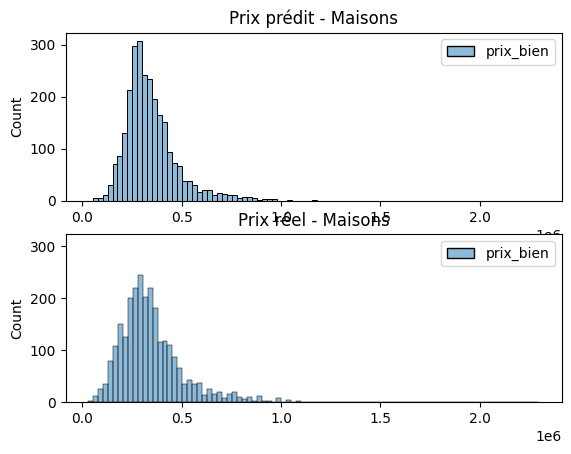

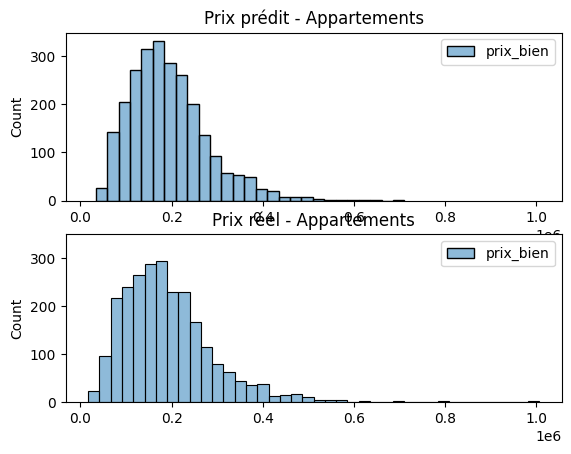

In [196]:
ax1 = plt.subplot(2,1,1)
sns.histplot(rf_pred_maisons, binwidth=25000)
plt.title('Prix prédit - Maisons')
ax2 = plt.subplot(2,1,2, sharex=ax1, sharey=ax1)
sns.histplot(y_test_maisons, binwidth=25000)
plt.title('Prix réel - Maisons')
plt.show()
ax1 = plt.subplot(2,1,1)
sns.histplot(rf_pred_appartements, binwidth=25000)
plt.title('Prix prédit - Appartements')
ax2 = plt.subplot(2,1,2, sharex=ax1, sharey=ax1)
sns.histplot(y_test_appartements, binwidth=25000)
plt.title('Prix réel - Appartements')
plt.show()

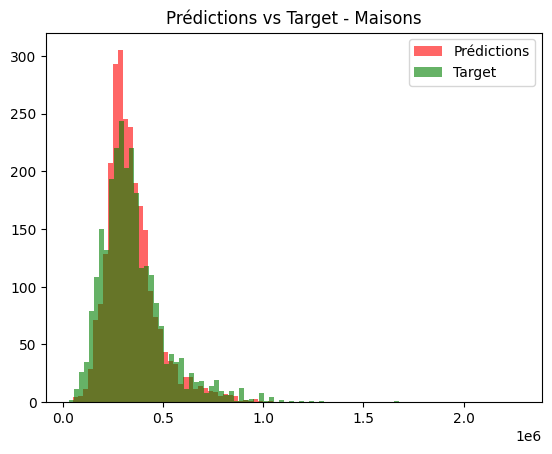

In [197]:
plt.hist(rf_pred_maisons, bins=range(round(min(rf_pred_maisons['prix_bien'])), round(max(rf_pred_maisons['prix_bien'])), 25000), color='red', alpha=0.6, label='Prédictions')
plt.hist(y_test_maisons, bins=range(round(min(y_test_maisons['prix_bien'])), round(max(y_test_maisons['prix_bien'])), 25000), color='green', alpha=0.6, label='Target')
plt.legend()
plt.title('Prédictions vs Target - Maisons')
plt.show()


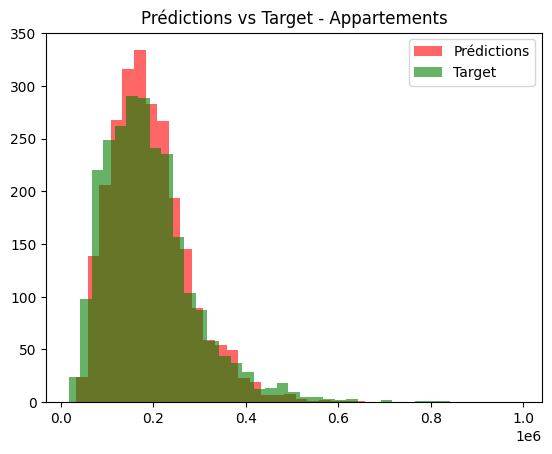

In [198]:
plt.hist(rf_pred_appartements, bins=range(round(min(rf_pred_appartements['prix_bien'])), round(max(rf_pred_appartements['prix_bien'])), 25000), color='red', alpha=0.6, label='Prédictions')
plt.hist(y_test_appartements, bins=range(round(min(y_test_appartements['prix_bien'])), round(max(y_test_appartements['prix_bien'])), 25000), color='green', alpha=0.6, label='Target')
plt.legend()
plt.title('Prédictions vs Target - Appartements')
plt.show()


In [199]:
delta_appartements = y_test_appartements - rf_pred_appartements
delta_appartements.head()

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-179786.03
ag680297-277810664,-14066.50
orpi-1-054041E1OWKF,5442.60
guy-hoquet-immo-facile-6243822,-13715.60
ag440414-293552741,66959.20


In [200]:
delta_maisons = y_test_maisons - rf_pred_maisons
delta_maisons.head()

,prix_bien
idannonce,
hektor-CGAIMMOBILIER-913,-55172.20
immo-facile-51717740,-36332.86
orpi-1-054932E20PLN,-55440.70
ag681156-273638219,-6468.46
mgc-343363639-pp-220513-102302,78856.01


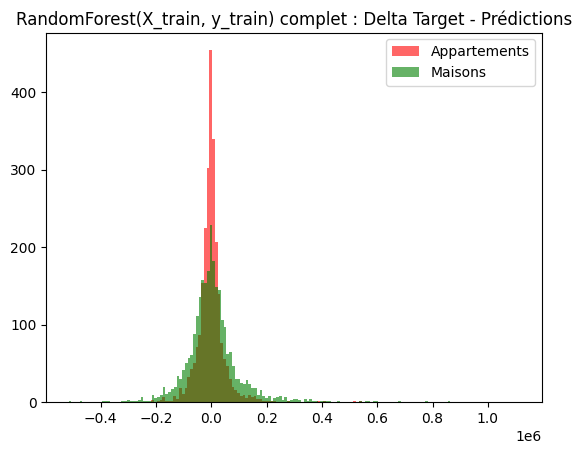

In [201]:
plt.hist(delta_appartements, bins=range(round(min(delta_appartements['prix_bien'])), round(max(delta_appartements['prix_bien'])), 10000), color='red', alpha=0.6, label='Appartements')
plt.hist(delta_maisons, bins=range(round(min(delta_maisons['prix_bien'])), round(max(delta_maisons['prix_bien'])), 10000), color='green', alpha=0.6, label='Maisons')
plt.legend()
plt.title('RandomForest(X_train, y_train) complet : Delta Target - Prédictions')
plt.show()

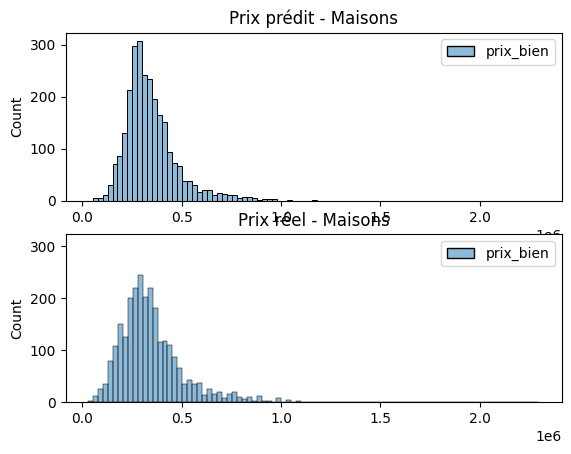

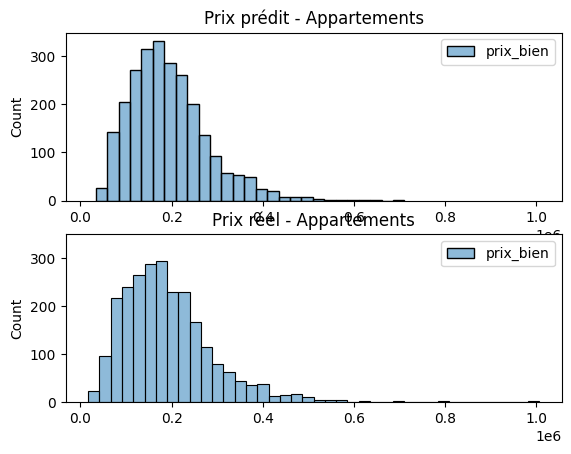

In [202]:
ax1 = plt.subplot(2,1,1)
sns.histplot(rf_pred_maisons, binwidth=25000)
plt.title('Prix prédit - Maisons')
ax2 = plt.subplot(2,1,2, sharex=ax1, sharey=ax1)
sns.histplot(y_test_maisons, binwidth=25000)
plt.title('Prix réel - Maisons')
plt.show()
ax1 = plt.subplot(2,1,1)
sns.histplot(rf_pred_appartements, binwidth=25000)
plt.title('Prix prédit - Appartements')
ax2 = plt.subplot(2,1,2, sharex=ax1, sharey=ax1)
sns.histplot(y_test_appartements, binwidth=25000)
plt.title('Prix réel - Appartements')
plt.show()

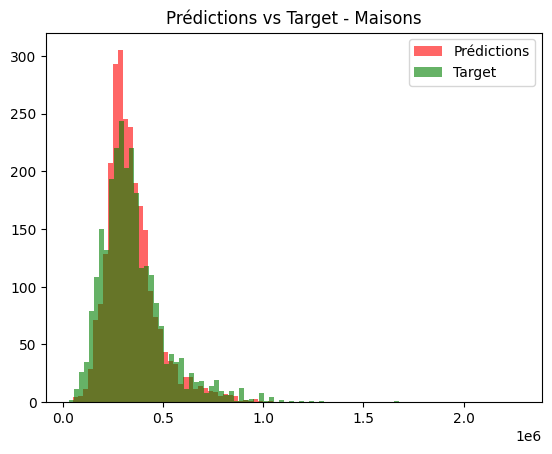

In [203]:
plt.hist(rf_pred_maisons, bins=range(round(min(rf_pred_maisons['prix_bien'])), round(max(rf_pred_maisons['prix_bien'])), 25000), color='red', alpha=0.6, label='Prédictions')
plt.hist(y_test_maisons, bins=range(round(min(y_test_maisons['prix_bien'])), round(max(y_test_maisons['prix_bien'])), 25000), color='green', alpha=0.6, label='Target')
plt.legend()
plt.title('Prédictions vs Target - Maisons')
plt.show()


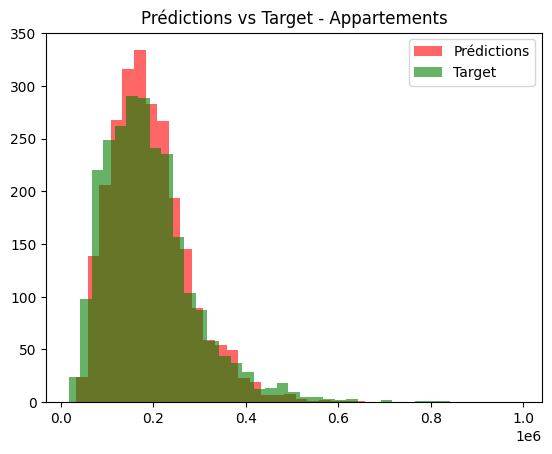

In [204]:
plt.hist(rf_pred_appartements, bins=range(round(min(rf_pred_appartements['prix_bien'])), round(max(rf_pred_appartements['prix_bien'])), 25000), color='red', alpha=0.6, label='Prédictions')
plt.hist(y_test_appartements, bins=range(round(min(y_test_appartements['prix_bien'])), round(max(y_test_appartements['prix_bien'])), 25000), color='green', alpha=0.6, label='Target')
plt.legend()
plt.title('Prédictions vs Target - Appartements')
plt.show()


In [205]:
delta_appartements = y_test_appartements - rf_pred_appartements
delta_appartements.head()

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-179786.03
ag680297-277810664,-14066.50
orpi-1-054041E1OWKF,5442.60
guy-hoquet-immo-facile-6243822,-13715.60
ag440414-293552741,66959.20


In [206]:
delta_maisons = y_test_maisons - rf_pred_maisons
delta_maisons.head()

,prix_bien
idannonce,
hektor-CGAIMMOBILIER-913,-55172.20
immo-facile-51717740,-36332.86
orpi-1-054932E20PLN,-55440.70
ag681156-273638219,-6468.46
mgc-343363639-pp-220513-102302,78856.01


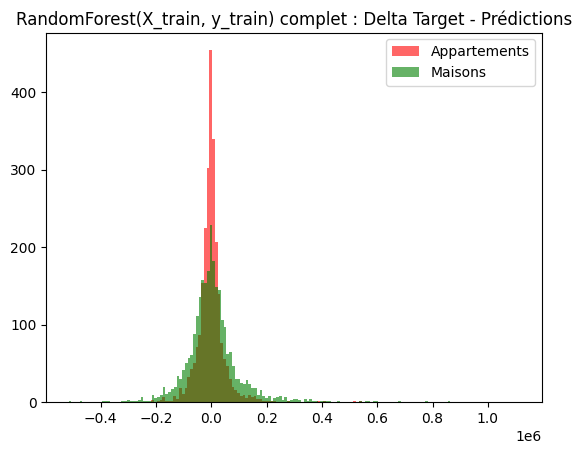

In [207]:
plt.hist(delta_appartements, bins=range(round(min(delta_appartements['prix_bien'])), round(max(delta_appartements['prix_bien'])), 10000), color='red', alpha=0.6, label='Appartements')
plt.hist(delta_maisons, bins=range(round(min(delta_maisons['prix_bien'])), round(max(delta_maisons['prix_bien'])), 10000), color='green', alpha=0.6, label='Maisons')
plt.legend()
plt.title('RandomForest(X_train, y_train) complet : Delta Target - Prédictions')
plt.show()